<a href="https://colab.research.google.com/github/varshacode01/varshacode01/blob/main/SelfWrap_Material_Failure_Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Predicting Early Material Failure in SelfWrap (Quality Engineering)**

 This model predicts early material failure using simulated degradation test data. The model shows how porosity, thickness, and temperature influence mechanical integrity. This could help Venostent flag high-risk batches early and optimize material parameters

 Goal:
Use dummy degradation test data to predict which material samples will fail early (lose strength too fast)

*How can this help VenoStent?*

This project uses simulated degradation test data to predict early material failure in VenoStent’s SelfWrap device. By modeling relationships between polymer thickness, porosity, temperature, and degradation time, the analysis identifies the key parameters that drive premature loss of mechanical strength. Using a Random Forest classifier, I built a predictive tool that could help the quality engineering team flag high-risk material batches early, optimize process parameters, and reduce test iteration cycles — ultimately improving consistency and accelerating design validation.

              precision    recall  f1-score   support

           1       1.00      1.00      1.00        60

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


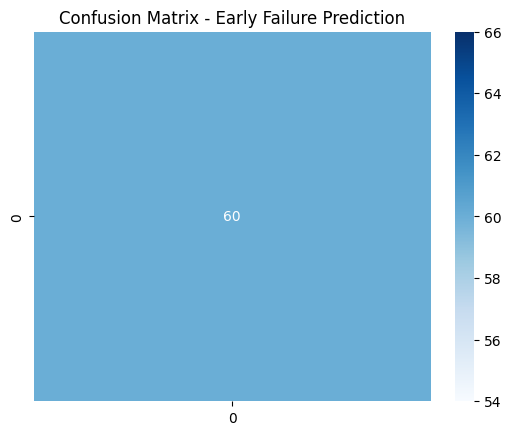

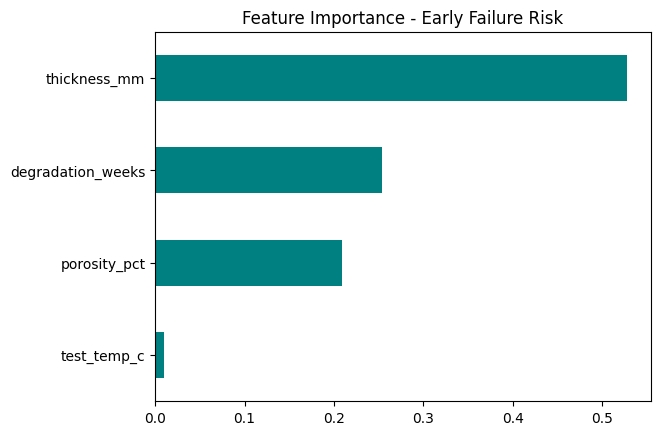

In [1]:
# Predicting Early Material Failure
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

# Simulate dummy data
np.random.seed(42)
n = 200
data = pd.DataFrame({
    "thickness_mm": np.random.uniform(0.2, 0.5, n),
    "porosity_pct": np.random.uniform(30, 60, n),
    "test_temp_c": np.random.choice([35, 37, 39], n),
    "degradation_weeks": np.random.uniform(4, 12, n)
})

# Simulate strength drop
data["tensile_strength_mpa"] = (
    80 * data["thickness_mm"] -
    0.5 * data["porosity_pct"] -
    2 * (data["test_temp_c"] - 37) -
    3 * (12 - data["degradation_weeks"]) +
    np.random.normal(0, 5, n)
)

# Define failure: < 20 MPa strength = early failure
data["early_failure"] = (data["tensile_strength_mpa"] < 20).astype(int)

# Split + train model
X = data[["thickness_mm", "porosity_pct", "test_temp_c", "degradation_weeks"]]
y = data["early_failure"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
preds = model.predict(X_test)

# Results
print(classification_report(y_test, preds))
sns.heatmap(confusion_matrix(y_test, preds), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Early Failure Prediction")
plt.show()

# Feature importance
feat_imp = pd.Series(model.feature_importances_, index=X.columns)
feat_imp.sort_values().plot(kind='barh', color='teal')
plt.title("Feature Importance - Early Failure Risk")
plt.show()


Properties of the material

*thermo-responsive shape memory polymer (SMP)*
(usually a polylactide)

**Elasticity (Flexibility):** Shape memory polymers are known for their high strain capacity, able to withstand strains up to 800% in a soft, rubbery state, which significantly surpasses traditional metallic or other polymeric medical materials. This high elasticity allows the device to conform to the surrounding vessel and accommodate changes in vessel size and blood flow (vasomotion) during healing, minimizing compliance mismatch with the native vessel.

**Durability (Mechanical Strength):** While in its temporary, rigid shape (below its glass transition temperature), the material provides sufficient initial radial support to prevent vessel recoil and maintain the desired shape. However, a general challenge with bioabsorbable polymers compared to metallic stents is lower inherent mechanical strength and higher fracture sensitivity, issues that VenoStent aims to address through material optimization and design.

**Longevity and Degradation:** The material is designed for temporary use. It provides support during the initial 6-12 week critical healing phase for an AV fistula maturation, after which it gradually degrades. The degradation process is designed to be complete over a specific timeframe, typically many months to a year or more, depending on the specific polymer type and molecular weight.

Modelling **Degradation Rate** of the material is shown below.

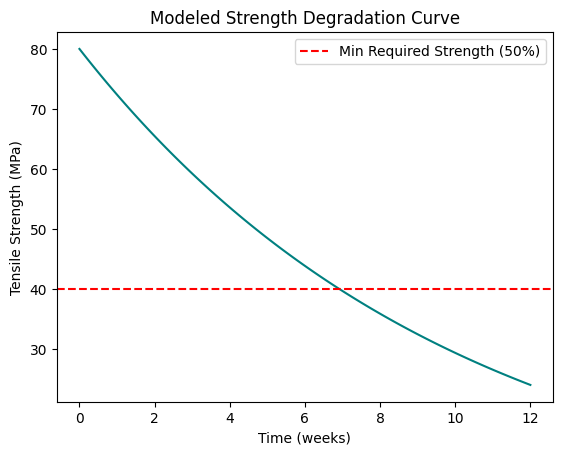

In [1]:
# Define a simple degradation model
import numpy as np
import matplotlib.pyplot as plt

weeks = np.linspace(0, 12, 100)
S0 = 80  # initial tensile strength (MPa)
k = 0.1  # degradation rate constant (per week)
strength = S0 * np.exp(-k * weeks)

plt.plot(weeks, strength, color='teal')
plt.xlabel("Time (weeks)")
plt.ylabel("Tensile Strength (MPa)")
plt.title("Modeled Strength Degradation Curve")
plt.axhline(40, color='r', linestyle='--', label='Min Required Strength (50%)')
plt.legend()
plt.show()


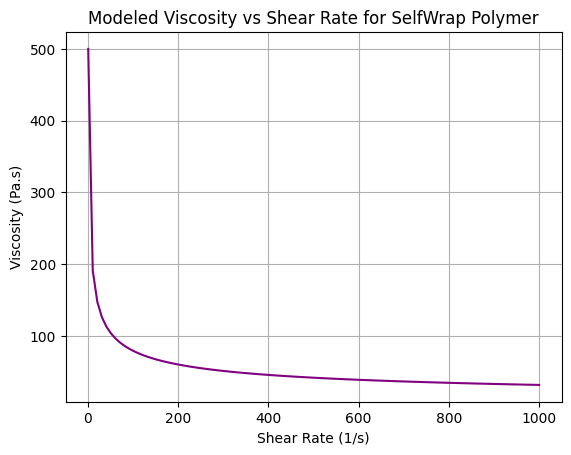

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Simulated parameters
shear_rate = np.linspace(1, 1000, 100)  # 1/s
K = 500  # consistency index
n = 0.6  # shear-thinning index

# Power-law model
viscosity = K * shear_rate**(n-1)

plt.plot(shear_rate, viscosity, color='purple')
plt.xlabel("Shear Rate (1/s)")
plt.ylabel("Viscosity (Pa.s)")
plt.title("Modeled Viscosity vs Shear Rate for SelfWrap Polymer")
plt.grid(True)
plt.show()



   age  diabetes  hypertension  vascular_elasticity  wrap_thickness  \
0   64         1             0             0.827723        0.440342   
1   36         0             0             0.823908        0.488355   
2   56         0             0             1.192440        0.566340   
3   57         0             1             0.989428        0.512351   
4   51         1             0             0.843796        0.526957   

   degradation_rate  maturation_score  
0         10.910185          0.479583  
1          8.365150          0.927231  
2         11.106545          1.000000  
3          9.012480          0.816861  
4          5.391795          0.698966  


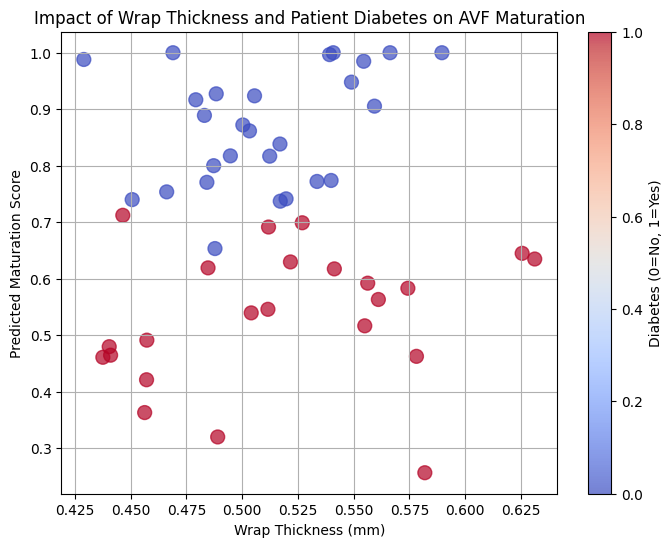

In [8]:
import numpy as np
import pandas as pd

# Dummy patient data
n_patients = 50
data = pd.DataFrame({
    "age": np.random.randint(30, 80, n_patients),
    "diabetes": np.random.choice([0,1], n_patients),
    "hypertension": np.random.choice([0,1], n_patients),
    "vascular_elasticity": np.random.normal(1.0, 0.2, n_patients),
    "wrap_thickness": np.random.normal(0.5, 0.05, n_patients),  # mm
    "degradation_rate": np.random.normal(10, 2, n_patients)      # % per week
})

# Simplified maturation score formula
data["maturation_score"] = (
    0.4*(1 - data["diabetes"]) +
    0.2*(1 - data["hypertension"]) +
    0.2*data["vascular_elasticity"] +
    0.1*(data["wrap_thickness"]/0.5) +
    0.1*(10/data["degradation_rate"]) +
    np.random.normal(0,0.05,n_patients)  # noise
)

data["maturation_score"] = data["maturation_score"].clip(0,1)

print(data.head())

import matplotlib.pyplot as plt

# Scatter plot: wrap thickness vs maturation_score
plt.figure(figsize=(8,6))
scatter = plt.scatter(
    data["wrap_thickness"],
    data["maturation_score"],
    c=data["diabetes"],  # color by diabetes (0=no,1=yes)
    cmap="coolwarm",
    s=100,
    alpha=0.7
)

plt.xlabel("Wrap Thickness (mm)")
plt.ylabel("Predicted Maturation Score")
plt.title("Impact of Wrap Thickness and Patient Diabetes on AVF Maturation")
plt.colorbar(scatter, label="Diabetes (0=No, 1=Yes)")
plt.grid(True)
plt.show()


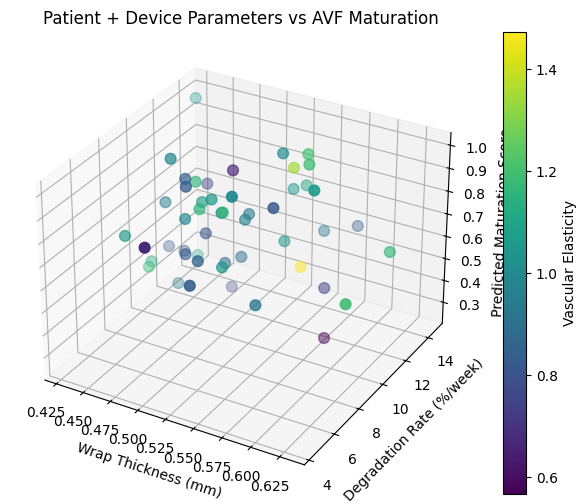

In [10]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
p = ax.scatter(
    data["wrap_thickness"],
    data["degradation_rate"],
    data["maturation_score"],
    c=data["vascular_elasticity"], cmap="viridis", s=60
)

ax.set_xlabel("Wrap Thickness (mm)")
ax.set_ylabel("Degradation Rate (%/week)")
ax.set_zlabel("Predicted Maturation Score")
fig.colorbar(p, label="Vascular Elasticity")
plt.title("Patient + Device Parameters vs AVF Maturation")
plt.show()
